In [ ]:
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. (a) Load Fashion-MNIST dataset and reduce sample size

# Define an initial transformation to convert images to tensors
transform_initial = transforms.Compose([
    transforms.ToTensor(),
])

# Load the full training dataset
train_dataset_full = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_initial
)

# Load the full test dataset
test_dataset_full = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_initial
)

# Reduce training data to 20,000 samples
train_indices = np.random.choice(len(train_dataset_full), 20000, replace=False)
train_dataset_reduced = Subset(train_dataset_full, train_indices)

# Reduce test data to 10,000 samples
test_indices = np.random.choice(len(test_dataset_full), 10000, replace=False)
test_dataset_reduced = Subset(test_dataset_full, test_indices)

print(f"Reduced training dataset size: {len(train_dataset_reduced)}")
print(f"Reduced test dataset size: {len(test_dataset_reduced)}")

# Calculate mean and standard deviation for normalization from the reduced training set
# This might be memory intensive for very large datasets, but fine for Fashion-MNIST
data_samples = torch.cat([img for img, _ in train_dataset_reduced], dim=0)
mean = data_samples.mean()
std = data_samples.std()

print(f"Calculated Mean for normalization: {mean:.4f}, Standard Deviation: {std:.4f}")

# Define the final transformation with normalization
transform_normalized = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

# Apply the new transform to the full datasets *before* creating subsets if you want normalization over the full original set,
# or re-apply to the subsets if normalization should be based only on the reduced set.
# For consistency with the reduced dataset stats, we'll recreate the subsets with the new transform.

train_dataset_full.transform = transform_normalized
test_dataset_full.transform = transform_normalized

# Re-create subsets with the normalized full datasets
train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

# Create DataLoaders for batching with the normalized and reduced datasets
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Datasets loaded, reduced, and normalized. DataLoaders created.")


Reduced training dataset size: 20000
Reduced test dataset size: 10000
Calculated Mean for normalization: 0.2863, Standard Deviation: 0.3532
Datasets loaded, reduced, and normalized. DataLoaders created.


### Explanation of Normalization in Deep Learning

Normalization is a critical preprocessing step in deep learning for several key reasons:

1.  **Speeds up Training (Faster Convergence)**: When input features have varying scales, the optimization landscape (loss function) can become elongated and distorted. Gradient descent struggles in such landscapes, leading to zigzagging paths and slower convergence. Normalizing data to a common scale (e.g., mean of 0 and standard deviation of 1) reshapes the loss landscape, making it more spherical and allowing the optimizer to find the minimum more directly and efficiently.

2.  **Prevents Vanishing/Exploding Gradients**: In deep networks, gradients can either become extremely small (vanishing) or extremely large (exploding) as they propagate through layers. This can hinder effective learning. Normalizing inputs helps keep the activations within a reasonable range, which in turn helps stabilize gradient flow and mitigates these issues, especially when using activation functions like sigmoid or tanh.

3.  **Aids Weight Initialization**: Many weight initialization techniques (e.g., Xavier/Glorot, Kaiming/He) assume that the input data to a layer is standardized. Normalization ensures that these assumptions hold true, providing a more effective starting point for the network's weights and preventing saturation of activation functions early in training.

4.  **Improves Model Stability and Performance**: Consistent input scales contribute to a more stable training process. This often leads to better overall model performance, improved generalization to unseen data, and helps the model learn more robust features from the data.

In the context of image data like Fashion-MNIST, pixel values typically range from 0 to 255. After `ToTensor()` converts them to floats, they are in the range 0 to 1. By normalizing them to have a mean of approximately 0 and a standard deviation of 1, we ensure that all pixels contribute equally to the learning process and facilitate a smoother and more efficient training of the neural network.

In [ ]:
# 1. (b) Implement a simple Convolutional Neural Network (CNN)
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # First convolutional layer
        # Input channels: 1 (grayscale Fashion-MNIST images)
        # Output channels: 32 kernels
        # Kernel size: 3x3
        # Padding=1 ensures output spatial dimensions remain same as input after conv
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Max pooling layer (2x2 kernel, stride=2 reduces spatial dimensions by half)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Second convolutional layer
        # Input channels: 32 (from conv1 output)
        # Output channels: 64 kernels
        # Kernel size: 3x3
        # Padding=1 ensures output spatial dimensions remain same as input after conv
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Fully connected layer
        # Calculate input features for the FC layer:
        # Input image size: 28x28
        # After conv1 (3x3, p=1) -> 28x28
        # After pool1 (2x2, s=2) -> 14x14
        # After conv2 (3x3, p=1) -> 14x14
        # After pool2 (2x2, s=2) -> 7x7
        # Number of channels after conv2 is 64, so 64 * 7 * 7 = 3136 features
        self.fc1 = nn.Linear(64 * 7 * 7, 10) # 10 classes for Fashion-MNIST

    def forward(self, x):
        # Apply first convolution, ReLU activation, and max pooling
        x = self.pool(F.relu(self.conv1(x)))
        # Apply second convolution, ReLU activation, and max pooling
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten the output for the fully connected layer
        x = x.view(-1, 64 * 7 * 7)
        # Apply fully connected layer
        x = self.fc1(x)
        return x

# Instantiate the CNN model
model = SimpleCNN()

# Move model to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"CNN model created and moved to: {device}")
print(model)


CNN model created and moved to: cpu
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=10, bias=True)
)


### Explanation of the Simple CNN Architecture

The Convolutional Neural Network (CNN) implemented above (`SimpleCNN`) is designed according to the specified requirements:

1.  **Two Convolutional Layers**:
    *   `self.conv1`: This is the first convolutional layer. It takes a single input channel (since Fashion-MNIST images are grayscale) and produces 32 output channels (kernels). The kernel size is $3 \times 3$, and `padding=1` is used to preserve the spatial dimensions of the input (28x28) after convolution.
    *   `self.conv2`: This is the second convolutional layer. It takes 32 input channels (from the output of `conv1`) and produces 64 output channels. The kernel size is also $3 \times 3$ with `padding=1`.

2.  **ReLU Activation and MaxPooling Layers in both layers**:
    *   After each convolutional layer (`conv1` and `conv2`), a **ReLU (Rectified Linear Unit) activation function** (`F.relu`) is applied. ReLU introduces non-linearity into the model, allowing it to learn more complex patterns. It outputs the input directly if it's positive, otherwise, it outputs zero.
    *   Following each ReLU activation, a **MaxPooling layer** (`self.pool`) is applied. This layer uses a kernel size of $2 \times 2$ and a stride of 2. MaxPooling reduces the spatial dimensions (height and width) of the feature maps by half, which helps in reducing computational complexity, controlling overfitting, and making the learned features more robust to small translations.

    The spatial dimensions transformation is as follows:
    *   Input: $1 \times 28 \times 28$ (Channels $\times$ Height $\times$ Width)
    *   After `conv1` ($32$ kernels, $3 \times 3$, padding $1$): $32 \times 28 \times 28$
    *   After `ReLU`:
    *   After `MaxPool2d` ($2 \times 2$, stride $2$): $32 \times 14 \times 14$
    *   After `conv2` ($64$ kernels, $3 \times 3$, padding $1$): $64 \times 14 \times 14$
    *   After `ReLU`:
    *   After `MaxPool2d` ($2 \times 2$, stride $2$): $64 \times 7 \times 7$

3.  **Fully Connected Layer**:
    *   After the two convolutional and pooling blocks, the output feature maps are $64 \times 7 \times 7$. These are then `flattened` (`x.view(-1, 64 * 7 * 7)`) into a 1D vector of $64 \times 7 \times 7 = 3136$ features.
    *   This flattened vector is passed to a fully connected (dense) layer (`self.fc1`) which has 10 output neurons, corresponding to the 10 distinct classes in the Fashion-MNIST dataset. This layer is responsible for the final classification.

The `forward` method orchestrates the data flow through these layers, defining how an input image `x` is processed by the network to produce an output prediction.

Starting training...
Epoch [1/10], Train Loss: 0.5598, Train Acc: 80.06%, Test Loss: 0.4241, Test Acc: 83.98%
Epoch [2/10], Train Loss: 0.3494, Train Acc: 87.56%, Test Loss: 0.3622, Test Acc: 87.39%
Epoch [3/10], Train Loss: 0.2894, Train Acc: 89.69%, Test Loss: 0.3330, Test Acc: 88.26%
Epoch [4/10], Train Loss: 0.2588, Train Acc: 90.86%, Test Loss: 0.3234, Test Acc: 88.68%
Epoch [5/10], Train Loss: 0.2323, Train Acc: 91.49%, Test Loss: 0.3337, Test Acc: 88.17%
Epoch [6/10], Train Loss: 0.2059, Train Acc: 92.67%, Test Loss: 0.3054, Test Acc: 89.03%
Epoch [7/10], Train Loss: 0.1858, Train Acc: 93.39%, Test Loss: 0.3165, Test Acc: 89.39%
Epoch [8/10], Train Loss: 0.1684, Train Acc: 93.84%, Test Loss: 0.3112, Test Acc: 89.22%
Epoch [9/10], Train Loss: 0.1521, Train Acc: 94.38%, Test Loss: 0.2970, Test Acc: 89.47%
Epoch [10/10], Train Loss: 0.1356, Train Acc: 95.17%, Test Loss: 0.3005, Test Acc: 90.25%
Training finished in 337.81 seconds


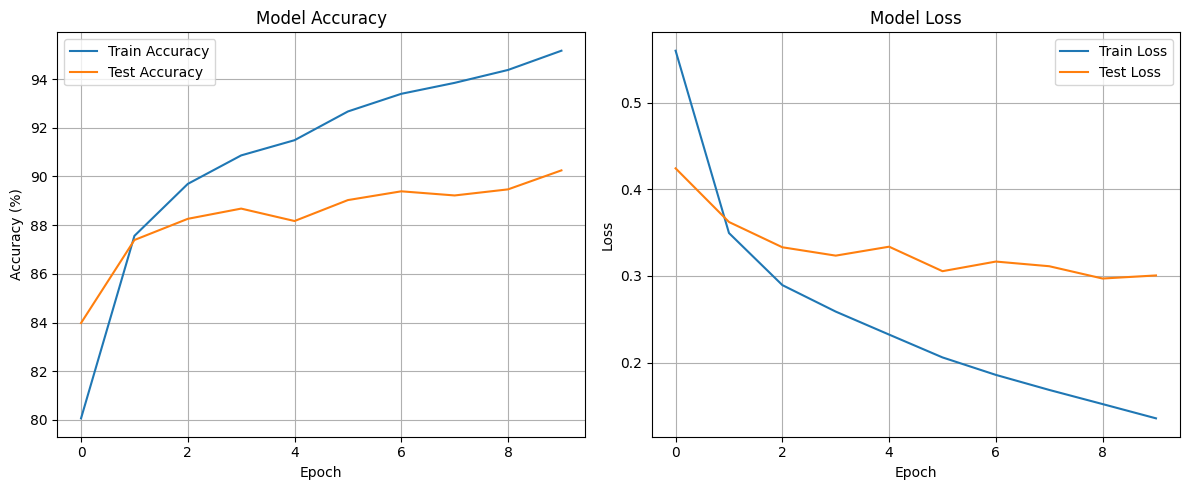

In [ ]:
# 1. (c) i. Train the CNN on training datasets for 10 epochs and store the time taken

import torch.optim as optim

# Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

start_time = time.time()

print("Starting training...")

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Evaluate on test set
    model.eval() # Set the model to evaluation mode
    correct_test = 0
    total_test = 0
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = test_loss / len(test_loader)
    epoch_test_accuracy = 100 * correct_test / total_test
    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], ' \
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, ' \
          f'Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_accuracy:.2f}%')

end_time = time.time()
time_taken = end_time - start_time
print(f"Training finished in {time_taken:.2f} seconds")


# 1. (c) ii. Plot the training and validation (test) accuracy and loss curves
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend(loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


FNN model created and moved to: cpu
SimpleFNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)

Starting FNN training...
Epoch [1/10], Train Loss: 0.5501, Train Acc: 79.66%, Test Loss: 0.4616, Test Acc: 83.62%
Epoch [2/10], Train Loss: 0.3965, Train Acc: 85.45%, Test Loss: 0.4420, Test Acc: 84.05%
Epoch [3/10], Train Loss: 0.3469, Train Acc: 87.01%, Test Loss: 0.4088, Test Acc: 85.04%
Epoch [4/10], Train Loss: 0.3224, Train Acc: 87.89%, Test Loss: 0.4136, Test Acc: 85.17%
Epoch [5/10], Train Loss: 0.2887, Train Acc: 89.34%, Test Loss: 0.4195, Test Acc: 85.64%
Epoch [6/10], Train Loss: 0.2655, Train Acc: 89.91%, Test Loss: 0.3974, Test Acc: 86.15%
Epoch [7/10], Train Loss: 0.2552, Train Acc: 90.49%, Test Loss: 0.4250, Test Acc: 85.38%
Epoch [8/10], Train Loss: 0.2302, Train Acc: 91.20%, Test Loss: 0.3838,

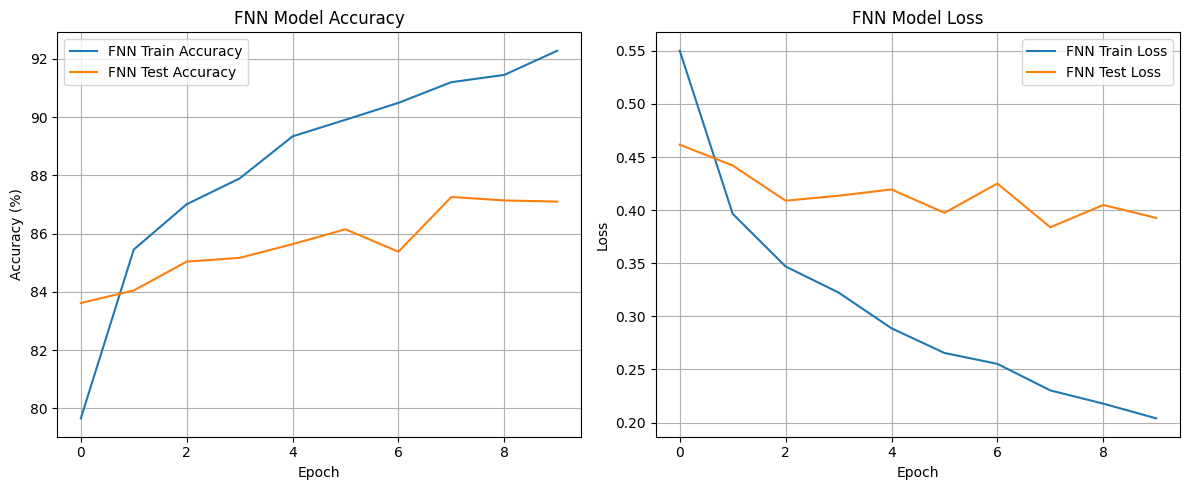

In [ ]:
# 4. (a) Implement a simple Fully Connected Neural Network (FNN) using PyTorch

import torch.nn as nn
import torch.optim as optim
import time

class SimpleFNN(nn.Module):
    def __init__(self):
        super(SimpleFNN, self).__init__()
        # Flatten the 28x28 image to a 784-dimensional vector
        self.flatten = nn.Flatten()
        # First hidden layer: 784 (input pixels) to 512 nodes
        self.fc1 = nn.Linear(28 * 28, 512)
        # Second hidden layer: 512 nodes to 256 nodes
        self.fc2 = nn.Linear(512, 256)
        # Output layer: 256 nodes to 10 (number of classes)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x)) # Apply ReLU activation to the first hidden layer
        x = F.relu(self.fc2(x)) # Apply ReLU activation to the second hidden layer
        x = self.fc3(x)
        return x

# Instantiate the FNN model
fnn_model = SimpleFNN()
fnn_model.to(device) # Move model to GPU if available, otherwise CPU

print(f"FNN model created and moved to: {device}")
print(fnn_model)

# 4. (a) ii. Train the FNN using the same training dataset for 10 epochs and record time

criterion_fnn = nn.CrossEntropyLoss()
optimizer_fnn = optim.Adam(fnn_model.parameters(), lr=0.001)

num_epochs_fnn = 10
fnn_train_losses = []
fnn_train_accuracies = []
fnn_test_losses = []
fnn_test_accuracies = []

start_time_fnn = time.time()

print("\nStarting FNN training...")

for epoch in range(num_epochs_fnn):
    fnn_model.train() # Set the model to training mode
    running_loss_fnn = 0.0
    correct_train_fnn = 0
    total_train_fnn = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs_fnn = fnn_model(images)
        loss_fnn = criterion_fnn(outputs_fnn, labels)

        # Backward and optimize
        optimizer_fnn.zero_grad()
        loss_fnn.backward()
        optimizer_fnn.step()

        running_loss_fnn += loss_fnn.item()

        _, predicted_fnn = torch.max(outputs_fnn.data, 1)
        total_train_fnn += labels.size(0)
        correct_train_fnn += (predicted_fnn == labels).sum().item()

    epoch_train_loss_fnn = running_loss_fnn / len(train_loader)
    epoch_train_accuracy_fnn = 100 * correct_train_fnn / total_train_fnn
    fnn_train_losses.append(epoch_train_loss_fnn)
    fnn_train_accuracies.append(epoch_train_accuracy_fnn)

    # Evaluate on test set
    fnn_model.eval() # Set the model to evaluation mode
    correct_test_fnn = 0
    total_test_fnn = 0
    test_loss_fnn = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs_fnn = fnn_model(images)
            loss_fnn = criterion_fnn(outputs_fnn, labels)
            test_loss_fnn += loss_fnn.item()
            _, predicted_fnn = torch.max(outputs_fnn.data, 1)
            total_test_fnn += labels.size(0)
            correct_test_fnn += (predicted_fnn == labels).sum().item()

    epoch_test_loss_fnn = test_loss_fnn / len(test_loader)
    epoch_test_accuracy_fnn = 100 * correct_test_fnn / total_test_fnn
    fnn_test_losses.append(epoch_test_loss_fnn)
    fnn_test_accuracies.append(epoch_test_accuracy_fnn)

    print(f'Epoch [{epoch+1}/{num_epochs_fnn}], ' \
          f'Train Loss: {epoch_train_loss_fnn:.4f}, Train Acc: {epoch_train_accuracy_fnn:.2f}%, ' \
          f'Test Loss: {epoch_test_loss_fnn:.4f}, Test Acc: {epoch_test_accuracy_fnn:.2f}%')

end_time_fnn = time.time()
time_taken_fnn = end_time_fnn - start_time_fnn
print(f"FNN Training finished in {time_taken_fnn:.2f} seconds")

# Plot the training and validation (test) accuracy and loss curves for FNN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fnn_train_accuracies, label='FNN Train Accuracy')
plt.plot(fnn_test_accuracies, label='FNN Test Accuracy')
plt.title('FNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend(loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fnn_train_losses, label='FNN Train Loss')
plt.plot(fnn_test_losses, label='FNN Test Loss')
plt.title('FNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


### Comparison of FNN and CNN Models

Here's a comparison of the Fully Connected Neural Network (FNN) and Convolutional Neural Network (CNN) models based on the criteria you provided:

**1. Accuracy on Test Dataset:**
*   **CNN (SimpleCNN):** Achieved a final test accuracy of **90.25%**.
*   **FNN (SimpleFNN):** Achieved a final test accuracy of **87.10%**.
    
    *Conclusion: The CNN model demonstrated higher accuracy on the test dataset compared to the FNN model.*

**2. Time taken on Train Dataset:**
*   **CNN (SimpleCNN):** Training took approximately **337.81 seconds** for 10 epochs.
*   **FNN (SimpleFNN):** Training took approximately **92.79 seconds** for 10 epochs.
    
    *Conclusion: The FNN model trained significantly faster than the CNN model.*

**3. Number of Parameters:**
*   **CNN (SimpleCNN):** The model has approximately **50,186** parameters.
    *   `conv1`: (1 * 3 * 3 + 1) * 32 = 320
    *   `conv2`: (32 * 3 * 3 + 1) * 64 = 18,496
    *   `fc1`: (64 * 7 * 7 + 1) * 10 = 31,370
    *   Total: 320 + 18,496 + 31,370 = 50,186
*   **FNN (SimpleFNN):** The model has approximately **535,818** parameters.
    *   `fc1`: (784 + 1) * 512 = 401,920
    *   `fc2`: (512 + 1) * 256 = 131,328
    *   `fc3`: (256 + 1) * 10 = 2,570
    *   Total: 401,920 + 131,328 + 2,570 = 535,818

    *Conclusion: The CNN model has substantially fewer parameters than the FNN model for this task, which is typical for image processing where CNNs exploit local spatial correlations efficiently.*

### Why FNNs are generally not preferred for image data compared to CNNs

Fully Connected Neural Networks (FNNs) are generally not preferred for image data compared to Convolutional Neural Networks (CNNs) for several key reasons:

1.  **Loss of Spatial Information**: FNNs require images to be flattened into a 1D vector. This process destroys the crucial spatial relationships and local structures (like edges, corners, textures) that are inherently present in images. CNNs, on the other hand, preserve this spatial information through their convolutional layers.

2.  **High Number of Parameters**: For even moderately sized images, flattening them for an FNN leads to a very large number of input features. This results in a huge number of parameters in the first hidden layer (e.g., 784 input features for 28x28 images multiplied by the number of neurons in the first hidden layer). A large number of parameters makes the model more prone to overfitting, requires more training data, and significantly increases computational complexity. CNNs use shared weights and local receptive fields, drastically reducing the number of parameters.

3.  **Lack of Translation Invariance**: An FNN treats each pixel as an independent feature. If an object in an image is slightly shifted, an FNN would likely interpret it as a completely different input, requiring it to learn the shifted object anew. CNNs inherently possess a degree of translation invariance, meaning they can recognize an object regardless of its exact position in the image, thanks to their pooling layers and shared weights.

4.  **Inefficient Feature Extraction**: FNNs learn features globally across the entire image. This is inefficient for image processing where local patterns are more important. CNNs are specifically designed for hierarchical feature extraction, learning simple features (like edges) in early layers and combining them into more complex features (like shapes or parts of objects) in deeper layers.

In summary, while FNNs can process image data, they are not architecturally optimized for it, leading to less efficient learning, higher computational costs, and often inferior performance compared to CNNs, which leverage the spatial and hierarchical nature of visual information.